#### Run the following only during the first time running the whole jupiter notebook

In [1]:
import os
import sys
current_dir = os.path.dirname(os.getcwd())
if not current_dir in sys.path:
    sys.path.append(current_dir)

# ----------------------------------------------------

In [2]:
import math
import torch
import sequence
import numpy as np
import torchkbnufft as tkbn
import matplotlib.pyplot as plt
from simulate.kernels import cpu_non_selective, cpu_relaxation, cpu_spatial_selective

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

img_size = 256

# values in seconds
t1_wm = 0.8         
t2_wm = 0.08
t1_myelin = 0.226         
t2_myelin = 300 * 1e-6

# Time Step
dt = 10 # unite: us

# Off-resonance frequencies
df = np.linspace(-500, 500, 200)


OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


## 1. Create T1 and T2 Maps

In [3]:
# Inner square (pure myelin)
square_size_inner = 80
top_inner = (img_size - square_size_inner) // 2
bottom_inner = (img_size + square_size_inner) // 2

# Mixed square (mixed signals)
square_size_mixed = 160
top_mixed = (img_size - square_size_mixed) // 2
bottom_mixed = (img_size + square_size_mixed) // 2

# Upper square
square_size_upper = 20
x0 = img_size//2 - square_size_upper//2
y0 = (img_size - square_size_mixed)//4 - square_size_upper//2
x1 = x0 + square_size_upper
y1 = y0 + square_size_upper




### (1) White Matter Maps

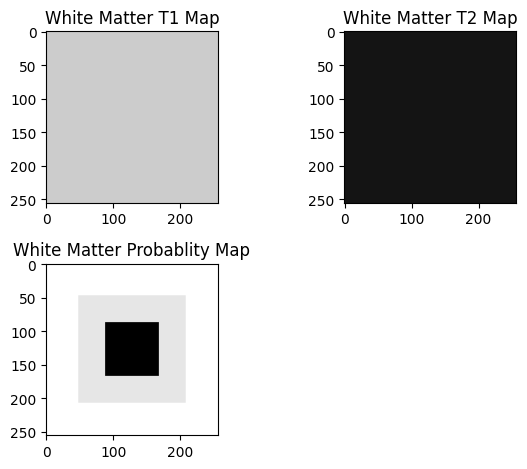

In [4]:
# T1 map
T1_map_wm = np.full([img_size, img_size], t1_wm, dtype=np.float64)


# T2 map
T2_map_wm = np.full([img_size, img_size], t2_wm, dtype=np.float64)


# Probability map
prob_map_wm = np.full([img_size, img_size], 1, dtype=np.float64)
prob_map_wm[top_mixed:bottom_mixed, top_mixed:bottom_mixed] = 0.9
prob_map_wm[top_inner:bottom_inner, top_inner:bottom_inner] = 0


plt.subplot(2,2,1)
plt.imshow(T1_map_wm, cmap='gray', vmin = 0, vmax = 1)
plt.title("White Matter T1 Map")

plt.subplot(2,2,2)
plt.imshow(T2_map_wm, cmap='gray', vmin = 0, vmax = 1)
plt.title("White Matter T2 Map")

plt.subplot(2,2,3)
plt.imshow(prob_map_wm, cmap='gray', vmin = 0, vmax = 1)
plt.title("White Matter Probablity Map")
plt.tight_layout()
plt.show()

### (2) Myelin Maps

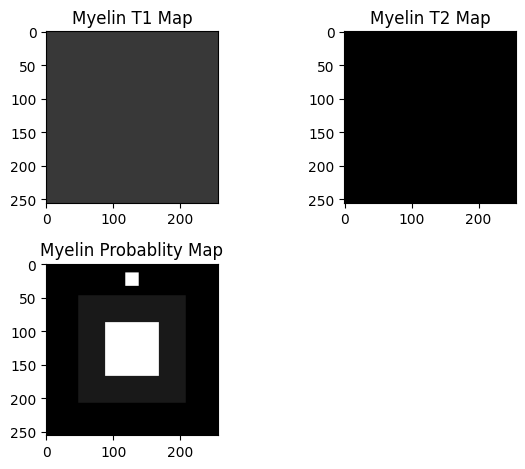

In [5]:
# T1 map
T1_map_myelin = np.full([img_size, img_size], t1_myelin, dtype=np.float64)


# # T2 map
T2_map_myelin = np.full([img_size, img_size], t2_myelin, dtype=np.float64)


# Probability map
prob_map_myelin = np.full([img_size, img_size], 0, dtype=np.float64)
prob_map_myelin[y0:y1, x0:x1] = 1
prob_map_myelin[top_mixed:bottom_mixed, top_mixed:bottom_mixed] = 0.1
prob_map_myelin[top_inner:bottom_inner, top_inner:bottom_inner] = 1


plt.subplot(2,2,1)
plt.imshow(T1_map_myelin, cmap='gray', vmin = 0, vmax = 1)
plt.title("Myelin T1 Map")

plt.subplot(2,2,2)
plt.imshow(T2_map_myelin, cmap='gray', vmin = 0, vmax = 1)
plt.title("Myelin T2 Map")

plt.subplot(2,2,3)
plt.imshow(prob_map_myelin, cmap='gray', vmin = 0, vmax = 1)
plt.title("Myelin Probablity Map")
plt.tight_layout()
plt.show()

## 2. Inversion Recovery

In [6]:
non_selective_dt = dt*1e-6
initial_magnetisation = np.array([0.0, 0.0, 1.0])

pulse = sequence.rf.hyperbolic_secant(1500, mu=5, bandwidth=2400, dt=dt)
optimal_amplitude = pulse.get_optimal_amplitude(torch.pi)
pulse.amplitude = optimal_amplitude
rf = pulse.waveform
rf = rf.detach().cpu().numpy().astype(np.complex128)


zero_padding = int(4.5/non_selective_dt)
rf_with_padding = np.pad(rf, (0, zero_padding))
print('Number of zero paddings:', zero_padding)

# white matter
magnetisation_wm_rf_with_padding = cpu_non_selective(t1_wm, t2_wm, non_selective_dt, df, rf_with_padding, initial_magnetisation)
print(magnetisation_wm_rf_with_padding.shape)

# myelin
magnetisation_myelin_rf_with_padding = cpu_non_selective(t1_myelin, t2_myelin, non_selective_dt, df, rf_with_padding, initial_magnetisation)
print(magnetisation_myelin_rf_with_padding.shape)




Number of zero paddings: 450000
(200, 450152, 3)
(200, 450152, 3)


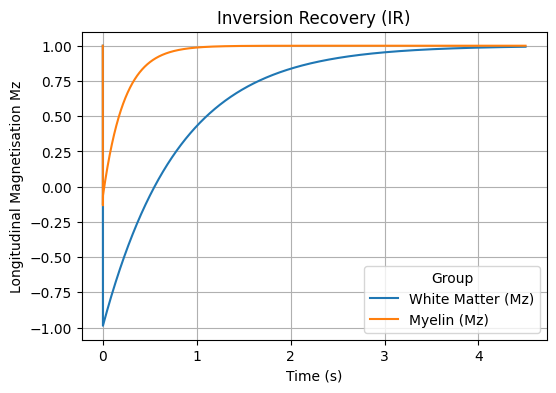

In [7]:
n_steps = magnetisation_wm_rf_with_padding.shape[1] -1
time = np.arange(n_steps + 1) * non_selective_dt  # seconds
plt.figure(figsize=(6,4))
plt.plot(time, magnetisation_wm_rf_with_padding[100, :, 2], label='White Matter (Mz)')
plt.plot(time, magnetisation_myelin_rf_with_padding[100, :, 2], label='Myelin (Mz)')
plt.xlabel('Time (s)')
plt.ylabel('Longitudinal Magnetisation Mz')
plt.title('Inversion Recovery (IR)')
plt.grid(True)
plt.legend(title='Group')
plt.show()

## 3. Calculate nulling point

In [8]:
n_inversion_steps = rf.shape[0]
array_wm = magnetisation_wm_rf_with_padding[100, n_inversion_steps + 1 :, 2]
idx = np.argmin(np.abs(array_wm))

n_nullout_step = n_inversion_steps + idx + 1
print(n_nullout_step) # Null out WM at: 0.55 s
t_nullout = n_nullout_step * dt
print(t_nullout)
print(magnetisation_myelin_rf_with_padding[100, n_nullout_step, :])

55066
550660
[-7.41098469e-323 -7.41098469e-323  9.06150445e-001]


## 4. 90 Degree Excitation (RF Pulse)

In [9]:
duration_sinc = 470
bw_sinc = 2700
dt_sinc = 10
tx_rx = 7
t_b4readout_sinc = duration_sinc + tx_rx
print(t_b4readout_sinc)
pulse_sinc = sequence.rf.hamming_sinc(duration_sinc, bw_sinc, dt = dt_sinc)
optimal_amplitude_sinc = pulse_sinc.get_optimal_amplitude(torch.pi/2)
pulse_sinc.amplitude = optimal_amplitude_sinc
#pulse_sinc.display()
rf_sinc = pulse_sinc.waveform
rf_sinc = rf_sinc.detach().cpu().numpy().astype(np.complex128)
print('optimal:', optimal_amplitude_sinc)



# WM
initial_magnetisation_wm_sinc = magnetisation_wm_rf_with_padding[100, n_nullout_step, :]
print('initial_magnetisation_wm_sinc:', n_nullout_step,initial_magnetisation_wm_sinc)

# Myelin
initial_magnetisation_myelin_sinc = magnetisation_myelin_rf_with_padding[100, n_nullout_step, :]
print('initial_magnetisation_myelin_sinc:', n_nullout_step,initial_magnetisation_myelin_sinc)

# Add padding for transverse recovery
zero_padding = int((1200-duration_sinc)/dt_sinc)
print('zero_padding:',zero_padding)
pulse_sinc_with_padding = np.pad(rf_sinc, (0, zero_padding))

magnetisation_wm_rf_sinc = cpu_non_selective(t1_wm, t2_wm, non_selective_dt, df, pulse_sinc_with_padding, initial_magnetisation_wm_sinc)
print(magnetisation_wm_rf_sinc.shape)
magnetisation_myelin_rf_sinc = cpu_non_selective(t1_myelin, t2_myelin, non_selective_dt, df, pulse_sinc_with_padding,  initial_magnetisation_myelin_sinc)
print('magnetisation_wm_rf_sinc:', magnetisation_wm_rf_sinc[100,-1,:])
print('magnetisation_myelin_rf_sinc:', magnetisation_myelin_rf_sinc[100,-1,:])




477
optimal: tensor(2.6078e-05)
initial_magnetisation_wm_sinc: 55066 [-6.83101603e-06  1.59889383e-05  2.56598092e-06]
initial_magnetisation_myelin_sinc: 55066 [-7.41098469e-323 -7.41098469e-323  9.06150445e-001]
zero_padding: 73
(200, 122, 3)
magnetisation_wm_rf_sinc: [-1.21631100e-05  3.56848276e-04  1.23194133e-03]
magnetisation_myelin_rf_sinc: [-0.00058554  0.0380953   0.20438086]


477


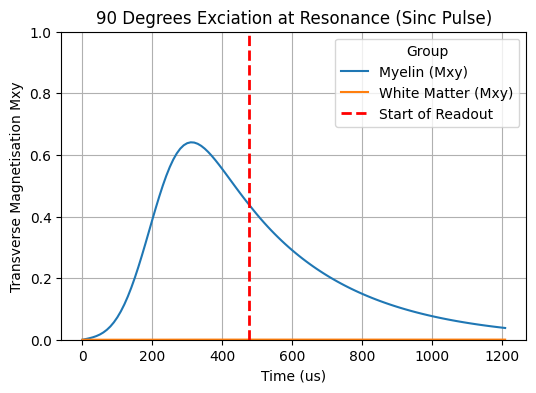

In [10]:
n_steps =  magnetisation_myelin_rf_sinc.shape[1]

time = np.arange(n_steps) * dt  # micro seconds

magnetisation_wm_rf_total_xy = np.sqrt(np.power(magnetisation_wm_rf_sinc[100, :, 0], 2) + np.power(magnetisation_wm_rf_sinc[100, :, 1], 2))
magnetisation_myelin_rf_total_xy = np.sqrt(np.power(magnetisation_myelin_rf_sinc[100, :, 0], 2) + np.power(magnetisation_myelin_rf_sinc[100, :, 1], 2))
print(t_b4readout_sinc)
plt.figure(figsize=(6,4))
plt.plot(time, magnetisation_myelin_rf_total_xy, label='Myelin (Mxy)')
plt.plot(time, magnetisation_wm_rf_total_xy, label='White Matter (Mxy)')

plt.axvline(x = t_b4readout_sinc, linestyle='--', linewidth=2, color = 'r', label = "Start of Readout")
plt.xlabel('Time (us)')
plt.ylabel('Transverse Magnetisation Mxy')
plt.ylim([0,1])
plt.title('90 Degrees Exciation at Resonance (Sinc Pulse)')
plt.grid(True)
plt.legend(title = "Group")
plt.show()

48
(200, 122, 3)
[-8.12371015e-06  3.60236959e-04  3.20149539e-04]


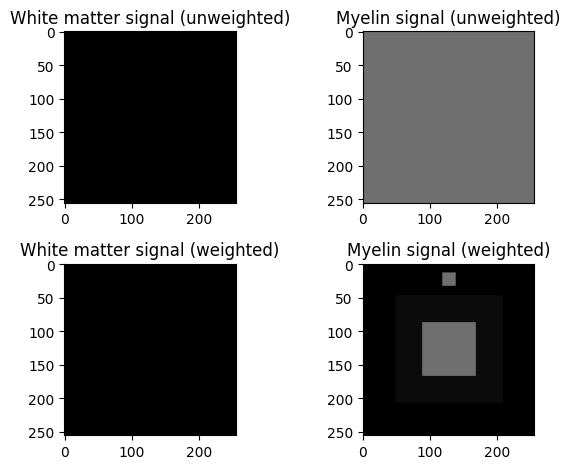

In [11]:
off_res_freq_index = 100
time_readout = int(np.round(t_b4readout_sinc/dt_sinc))
print(time_readout)

print(magnetisation_wm_rf_sinc.shape)
print(magnetisation_wm_rf_sinc[off_res_freq_index, time_readout, :])

magnetisation_wm_rf_total_xy = np.sqrt(np.power(magnetisation_wm_rf_sinc[off_res_freq_index, time_readout, 0], 2) + np.power(magnetisation_wm_rf_sinc[off_res_freq_index, time_readout, 1], 2))
magnetisation_myelin_rf_total_xy = np.sqrt(np.power(magnetisation_myelin_rf_sinc[off_res_freq_index, time_readout, 0], 2) + np.power(magnetisation_myelin_rf_sinc[off_res_freq_index, time_readout, 1], 2))

plt.subplot(2,2,1)
wm_signal = np.full([img_size, img_size], magnetisation_wm_rf_total_xy, dtype=np.float64)
plt.imshow(wm_signal, cmap='gray', vmin = 0, vmax = 1)
plt.title("White matter signal (unweighted)")

plt.subplot(2,2,2)
myelin_signal = np.full([img_size, img_size], magnetisation_myelin_rf_total_xy, dtype=np.float64)
plt.imshow(myelin_signal, cmap='gray', vmin = 0, vmax = 1)
plt.title("Myelin signal (unweighted)")

plt.subplot(2,2,3)
wm_signal_w = wm_signal * prob_map_wm
plt.imshow(wm_signal_w, cmap='gray', vmin = 0, vmax = 1)
plt.title("White matter signal (weighted)")

plt.subplot(2,2,4)
myelin_signal_w = myelin_signal * prob_map_myelin


plt.imshow(myelin_signal_w, cmap='gray', vmin = 0, vmax = 1)
plt.title("Myelin signal (weighted)")

plt.tight_layout()


## 5. Radial Sampling
We do radial sampling for two images respectively, then merge their k-space together

nspokes: 810
(256, 810)
(2, 207360)


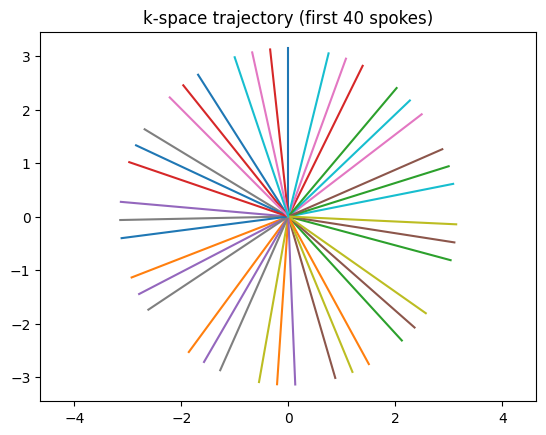

In [12]:
spokelength = img_size
grid_size = (spokelength*2, spokelength*2)
nspokes = int(np.ceil(spokelength * math.pi) + 5)
print('nspokes:', nspokes)
ga = np.deg2rad(180 / ((1 + np.sqrt(5)) / 2))
kx = np.zeros(shape=(spokelength, nspokes))
print(kx.shape)
ky = np.zeros(shape=(spokelength, nspokes))
ky[:, 0] = np.linspace(0, np.pi, spokelength)
for i in range(1, nspokes):
    kx[:, i] = np.cos(ga) * kx[:, i - 1] - np.sin(ga) * ky[:, i - 1]
    ky[:, i] = np.sin(ga) * kx[:, i - 1] + np.cos(ga) * ky[:, i - 1]
    
ky = np.transpose(ky)
kx = np.transpose(kx)

ktraj = np.stack((ky.flatten(), kx.flatten()), axis=0)

print(ktraj.shape)
# plot the first 40 spokes
plt.plot(kx[:40, :].transpose(), ky[:40, :].transpose())
plt.axis('equal')
plt.title('k-space trajectory (first 40 spokes)')
plt.show()

In [13]:
# convert k-space trajectory to a tensor
ktraj = torch.tensor(ktraj).to(device)
print('ktraj shape: {}'.format(ktraj.shape))

ktraj shape: torch.Size([2, 207360])


In [14]:
# create NUFFT objects, use 'ortho' for orthogonal FFTs
print(grid_size)
nufft_ob = tkbn.KbNufft(
    im_size=(img_size, img_size),
    grid_size=grid_size,
).to(device)
adjnufft_ob = tkbn.KbNufftAdjoint(
    im_size=(img_size, img_size),
    grid_size=grid_size,
).to(device)

print(nufft_ob)
print(adjnufft_ob)

(512, 512)

KbNufft
----------------------------------------
buffers
	tensor: table_0, shape: (6145,)
	tensor: table_1, shape: (6145,)
	tensor: im_size, shape: (2,)
	tensor: grid_size, shape: (2,)
	tensor: n_shift, shape: (2,)
	tensor: numpoints, shape: (2,)
	tensor: offsets, shape: (36, 2)
	tensor: table_oversamp, shape: (2,)
	tensor: order, shape: (2,)
	tensor: alpha, shape: (2,)
	tensor: scaling_coef, shape: (256, 256)


KbNufftAdjoint
----------------------------------------
buffers
	tensor: table_0, shape: (6145,)
	tensor: table_1, shape: (6145,)
	tensor: im_size, shape: (2,)
	tensor: grid_size, shape: (2,)
	tensor: n_shift, shape: (2,)
	tensor: numpoints, shape: (2,)
	tensor: offsets, shape: (36, 2)
	tensor: table_oversamp, shape: (2,)
	tensor: order, shape: (2,)
	tensor: alpha, shape: (2,)
	tensor: scaling_coef, shape: (256, 256)



### (1) White matter k-space

In [15]:
wm_signal_w = torch.as_tensor(wm_signal_w, device=device)  
wm_signal_w = wm_signal_w.to(torch.complex128)             
if wm_signal_w.ndim == 2:
    wm_signal_w = wm_signal_w[None, None, ...]          # add batch/channel dimension

ktraj = torch.as_tensor(ktraj, device=device).to(torch.float64)

print("wm_signal_w:", wm_signal_w.shape, wm_signal_w.dtype, wm_signal_w.device)
print("ktraj:", ktraj.shape, ktraj.dtype, ktraj.device)


with torch.no_grad():                            # forward (turn off gradient when no need, save memory)
    kdata_wm = nufft_ob(wm_signal_w, ktraj)

print(kdata_wm.shape)
siglevel_wm = torch.abs(kdata_wm).mean()
# kdata_wm = kdata_wm + (siglevel_wm/5) * torch.randn(kdata_wm.shape).to(kdata_wm)

noise_wm = torch.randn(kdata_wm.shape) + 1j * torch.randn(kdata_wm.shape)
noise_wm = noise_wm.to(kdata_wm)

kdata_wm = kdata_wm + (siglevel_wm/5) * noise_wm


print('kdata:', kdata_wm.dtype, kdata_wm.device, kdata_wm.shape)

wm_signal_w: torch.Size([1, 1, 256, 256]) torch.complex128 cpu
ktraj: torch.Size([2, 207360]) torch.float64 cpu
torch.Size([1, 1, 207360])
kdata: torch.complex128 cpu torch.Size([1, 1, 207360])


torch.Size([1, 1, 207360])


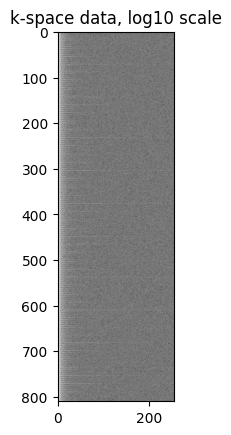

kdata_t: torch.complex128 cpu torch.Size([1, 1, 207360])
ktraj: torch.float64 cpu torch.Size([2, 207360])


In [16]:
# plot the k-space data on log-scale
t = np.linspace(0,0.001, spokelength)
kdata_numpy_wm = np.reshape(kdata_wm.cpu().numpy(), (nspokes, spokelength)) * np.exp(-t/t2_wm)
print(kdata_wm.shape)

plt.imshow(np.log10(np.absolute(kdata_numpy_wm)))
plt.gray()
plt.title('k-space data, log10 scale')
plt.show()

kdata_t_wm = torch.from_numpy(kdata_numpy_wm).to(torch.complex128).reshape(1, 1, -1)
print('kdata_t:',kdata_t_wm.dtype, kdata_t_wm.device, kdata_t_wm.shape)
print('ktraj:',ktraj.dtype, ktraj.device, ktraj.shape)

### (2) Myelin k-space

In [17]:
myelin_signal_w = torch.as_tensor(myelin_signal_w, device=device)  
myelin_signal_w = myelin_signal_w.to(torch.complex128)             
if myelin_signal_w.ndim == 2:
    myelin_signal_w = myelin_signal_w[None, None, ...]          # add batch/channel dimension

ktraj = torch.as_tensor(ktraj, device=device).to(torch.float64)

print("myelin_signal_w:", myelin_signal_w.shape, myelin_signal_w.dtype, myelin_signal_w.device)
print("ktraj:", ktraj.shape, ktraj.dtype, ktraj.device)


with torch.no_grad():                            # forward (turn off gradient when no need, save memory)
    kdata_myelin = nufft_ob(myelin_signal_w, ktraj)


siglevel = torch.abs(kdata_myelin).mean()
# kdata_myelin = kdata_myelin + (siglevel/5) * torch.randn(kdata_myelin.shape).to(kdata_myelin)

# print('kdata:', kdata_myelin.dtype, kdata_myelin.device, kdata_myelin.shape)

noise_myelin = torch.randn(kdata_myelin.shape) + 1j * torch.randn(kdata_myelin.shape)
noise_myelin = noise_myelin.to(kdata_myelin)

kdata_myelin = kdata_myelin + (siglevel/5) * noise_myelin
print(kdata_myelin.shape)

myelin_signal_w: torch.Size([1, 1, 256, 256]) torch.complex128 cpu
ktraj: torch.Size([2, 207360]) torch.float64 cpu
torch.Size([1, 1, 207360])


(810, 256)


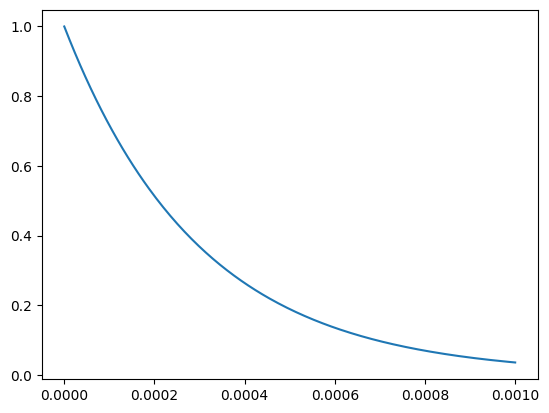

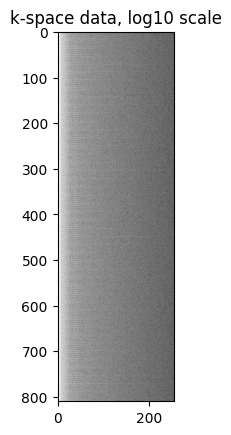

kdata_t: torch.complex128 cpu torch.Size([1, 1, 207360])
ktraj: torch.float64 cpu torch.Size([2, 207360])


In [ ]:
# plot the k-space data on log-scale
t = np.linspace(0,0.001, spokelength)

kdata_numpy_myelin = np.reshape(kdata_myelin.cpu().numpy(), (nspokes, spokelength)) * np.exp(-t/t2_myelin)
print(kdata_numpy_myelin.shape)
plt.plot(t, np.exp(-t/t2_myelin))
plt.show()

plt.imshow(np.log10(np.absolute(kdata_numpy_myelin)))
plt.gray()
plt.title('k-space data, log10 scale')
plt.show()

kdata_t_myelin = torch.from_numpy(kdata_numpy_myelin).to(torch.complex128).reshape(1, 1, -1)
print('kdata_t:',kdata_t_myelin.dtype, kdata_t_myelin.device, kdata_t_myelin.shape)
print('ktraj:',ktraj.dtype, ktraj.device, ktraj.shape)


In [19]:
# adjnufft back
# method 1: no density compensation (blurry image)
kdata_t = kdata_t_wm + kdata_t_myelin
image_blurry = adjnufft_ob(kdata_t, ktraj)

# method 2: use density compensation
dcomp = tkbn.calc_density_compensation_function(ktraj=ktraj, im_size=(img_size,img_size))
image_sharp = adjnufft_ob(kdata_t * dcomp, ktraj)
print(ktraj.shape)
print(dcomp.shape)

torch.Size([2, 207360])
torch.Size([1, 1, 207360])


[[2984817.29644794 2991274.46723157 2997900.94228865 ... 2994449.53007629
  2988333.24741656 2983261.4481265 ]
 [2991659.64576019 2997574.71721242 3003673.55109511 ... 2999729.99146312
  2993422.06914792 2989088.31735869]
 [2998605.78114129 3004784.45055192 3010208.9914126  ... 3007090.88540368
  3000508.42646864 2995371.35613395]
 ...
 [2951560.96370402 2957137.53036998 2963978.84435301 ... 2964947.93699417
  2961081.81274929 2956726.38311384]
 [2946528.66145968 2952643.71526144 2959535.80217507 ... 2958521.50610375
  2954698.75954724 2950240.37981816]
 [2941769.89376134 2948360.78142716 2954900.64385828 ... 2951035.02622569
  2946330.16545381 2941284.16906425]]


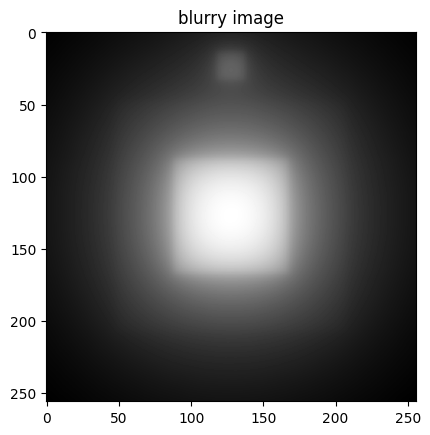

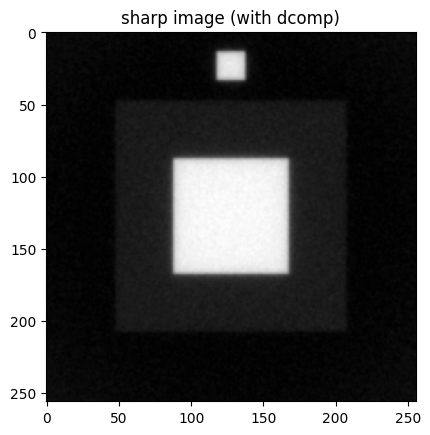

In [21]:
# show the images
image_blurry_numpy = np.squeeze(image_blurry.cpu().numpy())
image_sharp_numpy = np.squeeze(image_sharp.cpu().numpy())

plt.figure(0)
plt.imshow(np.absolute(image_blurry_numpy))
print(np.absolute(image_blurry_numpy))
plt.gray()
plt.title('blurry image')

plt.figure(1)
plt.imshow(np.absolute(image_sharp_numpy))
plt.gray()
plt.title('sharp image (with dcomp)')

plt.show()